# Laboratory 4: Generating Images with Diffusion Models

This laboratory covers:

* How the forward diffusion process gradually adds noise to images
* How the reverse diffusion process iteratively removes noise to create a clean image
* Training a denoising U-Net model
* Using the trained U-Net to generate clothing-item images

Broadly speaking, there are two ways to generate images from text prompts: Vision Transformers (ViT) and diffusion models. In the first method, we divide an image into multiple patches and treat each patch as an element in a sequence. As a result, image generation becomes a sequence prediction problem. When generating an image based on a text prompt, we ask the trained ViT to first predict the top left patch. In the next iteration, we feed the first patch, along with the text prompt, to the ViT and ask it to predict the second patch. We repeat the process until we have all the needed patches in the image.

The second way to generate images based on text descriptions is through diffusion models. We start with an image with pure noise. We ask the trained diffusion model to denoise it slightly, conditional on the text prompt. The result is a less noisy image. We repeat the process many times until we obtain a clean image that matches the text prompt. Diffusion models have become the go-to generative model by learning to progressively remove noise from noisy images. They form the foundation of the state-of-the-art text-to-image models, including Imagen, DALL-E 2 (though not DALL-E), and Stable Diffusion.

This laboratory discusses the basic idea behind diffusion models. Understanding the diffusion mechanism is particularly crucial for creating text-to-image models, as diffusion models form the foundation of many leading text-to-image models. For this reason, we will start by building and training a diffusion model to generate grayscale clothing-item images in this laboratory. This will provide us with a deep understanding of the forward diffusion process, where noise is incrementally added to images until they become random noise. Subsequently, we will train a model to reverse the diffusion process by gradually removing noise from images until the model can generate a new, clean image from random noise, resembling those in the training dataset.

Along the way, we will also learn different diffusion schedules that dictate how noise is added over time during the forward process. Different schedules, such as linear and cosine, impact both efficiency and model performance. A linear schedule gradually increases the noise level in each time step by a fixed, linearly increasing amount. Mathematically, it defines the variance of noise added in each time step as an increasing linear function of time. The linear noise schedule is simple and commonly used due to ease of implementation. The cosine schedule adjusts the noise variance in each time step using a cosine function. This leads to a non-linear progression where noise increases more gradually at first and then accelerates. The cosine schedule helps maintain finer details in initial diffusion steps, which can enhance model performance and output quality.

By the end of this laboratory, we will have built a solid foundation in diffusion models, equipping us to tackle more complex tasks in text-to-image generation. We will also gain practical experience with key concepts such as forward diffusion, reverse diffusion, and noise schedules—all of which are pivotal for mastering state-of-the-art generative AI techniques.

# 1.    The Forward Diffusion Process
The idea of diffusion-based models is as follows. Imagine we want to train a diffusion model to generate high-resolution images. We first acquire a set of images for training. We will gradually introduce small amounts of random noise into these images. This process is known as forward diffusion. After many steps of adding noise, the training images become pure random noise.

We will then train a model to reverse this process, a process known as the reverse diffusion process (or the denoising process). Specifically, we will start with random noise images and progressively reduce the noise until the images are indistinguishable from those in the original training set. The trained diffusion model can use random noise images as a starting point. It gradually eliminates noise from the image over many iterations until it generates a clean image. This is the underlying principle of diffusion-based models.

In this section, we will first explore the theoretical foundations of diffusion-based models. Then, we will explore two different ways of noise scheduling: the linear noise schedule and the cosine noise schedule. We will compare them side by side to see how noise is added to images until they become random noise images, similar to snowflakes on a TV screen.

## 1.1. How Diffusion Models Work

The idea behind diffusion models is proposed by several papers with similar underlying
mechanisms. In forward diffusion, noise is gradually added to a clean image
until it becomes pure noise. The step-by-step addition of noise is essential to create a
controllable and learnable process that bridges the gap between structured data and
random noise. It enables the model to learn incremental denoising steps during training
so that the trained model provides an effective and stable reverse process for generating
images. The figure below is a diagram of how the forward diffusion process works.

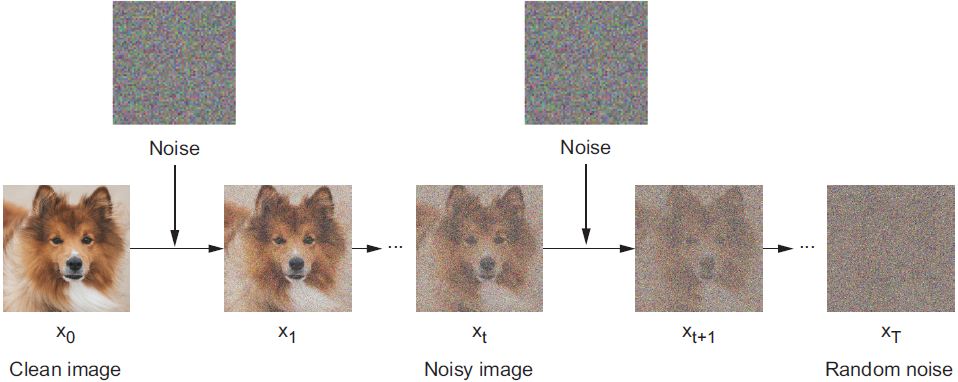

We start with a clean image, $x_0$, which is illustrated in the left image of a dog the figure above. The image $x_0$ follows a distribution of $q(x)$. We can normalize the value of $x$ so that
it has zero mean and unit standard deviation. In the forward diffusion process, we will
add small amounts of noise to the image in each of the $T$ time steps (e.g., $T = 1000$). The
noise tensor follows a standard normal distribution and has the same shape as the clean
image. Eventually, $x_T$ approximates a standard normal distribution.

In time step 1, we add noise $\epsilon_0$ to the image $x_0$ so that we obtain a noisy image $x_1$, as
follows:

\begin{equation}
\tag{1}
x_1=\sqrt{1-\beta_1}x_0+\sqrt{\beta_1}\epsilon_0.
\end{equation}

Here, $x_1$ is a weighted sum of $x_0$ and $\epsilon_0$, and $\sqrt{\beta_1}$ measures the weight placed on the
noise. The value of $𝛽$ changes in different time steps, hence the subscript in $𝛽_1$. Because
we assume $x_0$ and noise $\epsilon_0$ both have a mean of $0$ and variance of $1$, the noisy image $x_1$
will also have zero mean and unit variance. This is easy to prove as

\begin{equation}
\text{mean}(x_1)=\sqrt{1-\beta_1}\text{mean}(x_0)+\sqrt{\beta_1}\text{mean}(\epsilon_0)=0
\end{equation}

and

\begin{equation}
\tag{2}
\text{var}(x_1)=\text{var}(\sqrt{1-\beta_1}x_0)+\text{var}(\sqrt{\beta_1}\epsilon_0)=\\(1-\beta_1)\text{var}(x_0)+\beta_1\text{var}(\epsilon_0)=1-\beta_1+\beta_1=1.
\end{equation}

We keep adding noise to the image for the next $T-1$ time steps so that

\begin{equation}
\tag{3}
x_{t+1}=\sqrt{1-\beta_{t+1}}x_t+\sqrt{\beta_{t+1}}\epsilon_t.
\end{equation}

If we use a reparameterization trick and define $\alpha_t= 1 – 𝛽_t$ and $\bar{\alpha_t}=\prod_{k=1}^t\alpha_k$, we can
sample $x_t$ at any arbitrary time step $t$, where $t$ can take any value in $[1, 2, ..., T-1, T]$:

\begin{equation}
\tag{4}
x_{t}=\sqrt{\bar{\alpha_t}}x_0+\sqrt{1-\bar{\alpha_t}}\epsilon.
\end{equation}

Here, $\epsilon$ is a combination of $\epsilon_0, \epsilon_1, . . .$, and $\epsilon_{t–1}$, using the fact that we can add two normal
distributions to obtain a new normal distribution.

We will then construct a deep neural network as the denoising model to reverse the diffusion
process, which is called the denoising process. If we can train a model to reverse
the forward diffusion process, we can feed the model with random noise and ask it to
produce a noisy image. We can then feed the noisy image to the trained model again
and obtain a clearer, though still noisy, image. We can iteratively repeat the process
for many time steps until the output is a clean image. This is the idea behind diffusion models.

## 1.2. Visualizing the Forward Diffusion Process

The value of $β_t$ changes in different time steps, hence the subscript in $β_t$. There are different
ways of modeling the relation between $β_t$ and the time step $t$, for example, using
a linear diffusion schedule. That is, the value of $β_t$ increases linearly with the time
step $t$, ranging from $β_1 = 0.0001$ to $β_T = 0.02$. Let’s code that in Python.


In [ ]:
import torch

# assuming 1000 time steps
T=1000
# relative timesteps [0/1000, 1/1000,...,1000/1000]
t=torch.arange(0, T + 1,dtype=torch.float32)/T
def linear_scheduler():
    # values of beta1 and beta2
    beta1, beta2 = 0.0001, 0.02
    # beta_t increases linearly with time step t
    beta_t = (beta2 - beta1) * t  + beta1
    alpha_t = 1 - beta_t
    log_alpha_t = torch.log(alpha_t)
    # define alphabar_t
    alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()
    # the weight placed on the clean image x0
    sqrtab = torch.sqrt(alphabar_t)
    # the weight placed on noise 𝛆0
    sqrtmab = torch.sqrt(1 - alphabar_t)
    return {"sqrtab": sqrtab,"sqrtmab": sqrtmab}

We assume a total of $T = 1,000$ time steps. For simplicity, we define a list of $1,001$ relative
time steps $t = [0/1000, 1/1000, 2/1000, . . ., 1000/1000]$. We then define a function
`linear_scheduler()`. The value of $β_t$ increases linearly with the time step $t$. The
function returns a dictionary with two key–value pairs: the first one is the weight on the
clean image $x_0$, $\sqrt{\bar{α}_t}$, and the second is the weight on noise $\epsilon_0$, $\sqrt{1-\bar{α}_t}$.

To visualize how the forward diffusion process works, let’s apply the process to a few
images. Download the following four images: [`bird.png`](https://drive.google.com/file/d/17al7QkCrihd1_vYPenS0YmOvKbyS0jB1/view?usp=drive_link), [`dog.png`](https://drive.google.com/file/d/1PBaJ27NLVKtqXxjU3bVKQFxrD01z1oqC/view?usp=drive_link),
[`mountains.png`](https://drive.google.com/file/d/1_WjQazmBVcLK7hWDBPxPtxqAGOnXcQmK/view?usp=drive_link), and [`horse.png`](https://drive.google.com/file/d/153UyY9DMbPh9qeOj58mV81rOjPtWn23_/view?usp=drive_link). Place them in the `files` folder.

Run the following code block to visualize the forward diffusion process.

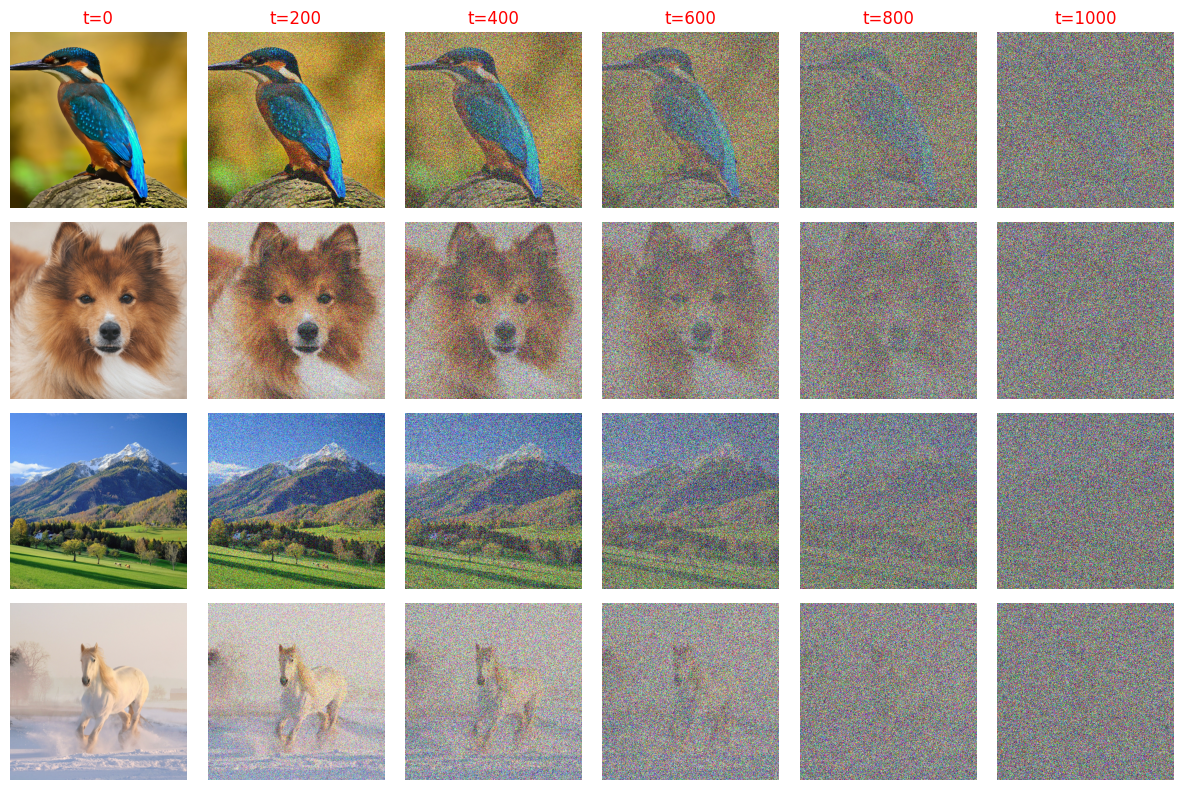

In [ ]:
import matplotlib.pyplot as plt
import PIL
import numpy as np
def linear_noisy_image(image,timestep):    #Defines a function to generate noisy images from clean images with a linear diffusion schedule
    alphabar_t=linear_scheduler()["sqrtab"][timestep]
    noisy=image*torch.sqrt(alphabar_t)+\
        torch.randn_like(image)*torch.sqrt(1 - alphabar_t)
    return torch.clip(noisy,min=-1,max=1)
imgs=[]
for name in ["bird","dog","mountains","horse"]:
    img=np.array(PIL.Image.open(f"files/{name}.png"))
    img=torch.tensor(2*(img/255)-1)
    for timestep in [0,200,400,600,800,1000]:    #Generates noisy images at time steps 0, 200, 400, . . ., 1,000
        imgs.append(linear_noisy_image(img,timestep)/2+0.5)
plt.figure(figsize=(12,8),dpi=100)
for i in range(24):
    plt.subplot(4,6,i+1)    #Plots the noisy images in four rows and six columns
    plt.imshow(imgs[i])
    if i<6:
        plt.title(f't={200*(i%6)}',fontsize=12,c="r")
    plt.axis("off")
plt.tight_layout()
plt.show()

We first define a function `linear_noisy_image()` to add noise to an image. The function
takes two arguments: `image`, which is a clean image that we want to add noise to,
and `timestep`, which is an integer that can take a value between $0$ and $1,000$. The result
is a noisy image based on the formula in equation $(4)$.

We then iterate through the $4$ images and the time steps $0, 200, 400, . . ., 1,000$ and use
the function `linear_noisy_image()` to generate $24$ images. The $24$ images are plotted
in four rows and six columns, as shown in the figure above. The $4$ images in the first column
are clean images. We then gradually
add noise to these images. As the time step increases, more and more noise is injected
into the images. The $4$ images in the second column are images after $200$ time steps.
The third column contains images after $400$ time steps, showing more noise than those
in the second column. The last column contains images after $1,000$ time steps, showing
pure random noise.

## 1.3 Different Diffusion Schedules

In 2021, A. Nichol and P. Dhariwal proposed a new noise schedule—a
cosine diffusion schedule. Because noisy images are used to train the denoising diffusion
models, the noise schedule affects how noise is added to images, which, in turn,
affects the effectiveness of the trained diffusion model. The authors found that the
cosine noise schedule outperformed (in image quality produced by trained models)
the linear diffusion schedule proposed in the paper by Ho et al. in 2020.

Specifically, in the proposed cosine diffusion schedule, the weights placed on the
clean images and noise are

\begin{equation}
\sqrt{\bar{\alpha_t}}=\cos\left(\frac{\pi t}{2T}\right),\sqrt{1-\bar{\alpha_t}}=\sin\left(\frac{\pi t}{2T}\right).
\end{equation}

That is, we can sample $x_t$ like this:

\begin{equation}
\tag{5}
x_t=\cos\left(\frac{\pi t}{2T}\right)x_0+\sin\left(\frac{\pi t}{2T}\right)\epsilon.
\end{equation}

Compared to the linear diffusion schedule, the cosine diffusion schedule adds noise to
the image more uniformly from time step $1$ to time step $T$. To see this, we run the following
code block.

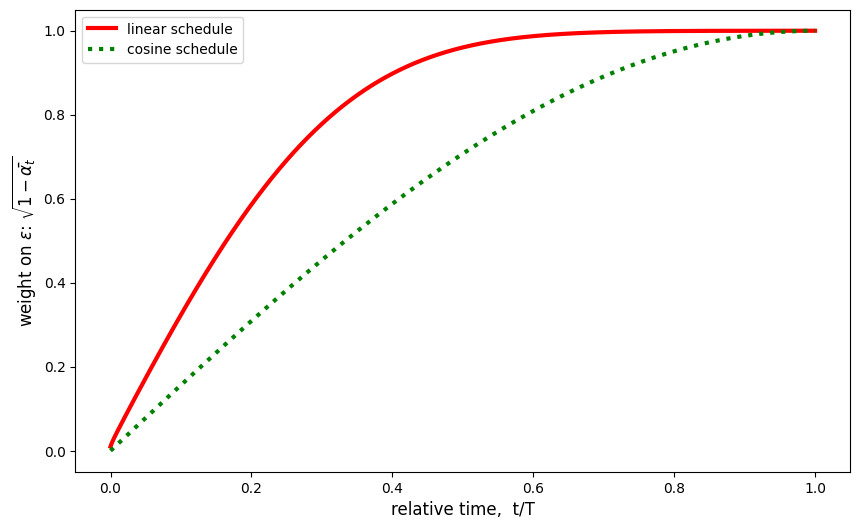

In [ ]:
import math
def cosine_scheduler():    #Defines the cosine diffusion scheduler
    sqrtab = torch.cos(0.5*math.pi*t)
    sqrtmab = torch.sin(0.5*math.pi*t)
    return {"sqrtab": sqrtab,"sqrtmab": sqrtmab}

plt.figure(figsize=(10,6),dpi=100)
plt.plot(t, linear_scheduler()["sqrtmab"], linewidth=3,    #Plots the weight on the noise over time under the linear scheduler
         linestyle="solid",c="r", label="linear schedule")
plt.plot(t, cosine_scheduler()["sqrtmab"], linewidth=3,    #Plots the weight on the noise over time under the cosine scheduler
         linestyle="dotted",c="g", label="cosine schedule")
plt.xlabel(r"relative time,  t/T", fontsize=12)
plt.ylabel(r"weight on $\epsilon$: $\sqrt{1-\bar{\alpha_t}}$",
           fontsize=12)
plt.legend()
plt.show()


We first define a function `cosine_scheduler()` to define the weight placed on the clean
image and that on the noise over time based on the cosine diffusion schedule. We then
plot the weights on the noise under both the linear diffusion schedule and the cosine
schedule in the same graph.

The solid line in the figure above is the weight on the noise over time under the linear
diffusion schedule. The weight is flat once the relative time step $t/T$ exceeds $0.6$. In
contrast, the dotted line, which represents the weight on the noise under the cosine
diffusion schedule, increases over time gradually, leading to better learning in diffusion
models.

We can also plot the weight on the clean image over time under the two diffusion
schedules. We run the following code block to produce the output shown below:

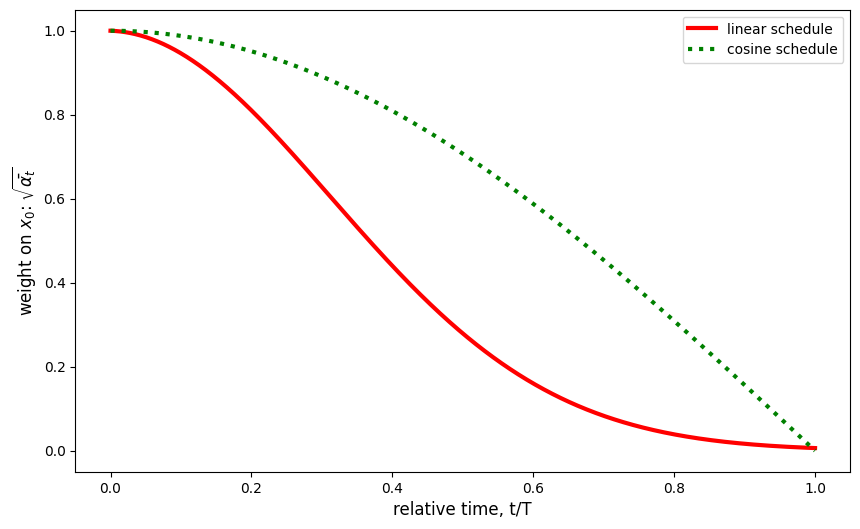

In [ ]:
plt.figure(figsize=(10,6),dpi=100)
plt.plot(t, linear_scheduler()["sqrtab"], linewidth=3,    #Plots the weight on the clean image over time under the linear scheduler
         linestyle="solid",c="r", label="linear schedule")
plt.plot(t, cosine_scheduler()["sqrtab"], linewidth=3,    #Plots the weight on the clean image over time under the cosine scheduler
         linestyle="dotted",c="g", label="cosine schedule")
plt.xlabel(r"relative time, t/T", fontsize=12)
plt.ylabel(r"weight on $x_0$: $\sqrt{\bar{\alpha_t}}$",
           fontsize=12)
plt.legend()
plt.show()


The solid line shows the weight on the clean image over time under the linear diffusion
schedule. The weight is flat once the relative time step $t/T$ exceeds $0.8$. In contrast, the
dotted line shows that the weight on the clean image under the cosine diffusion schedule
decreases over time more gradually.

To see how this affects the actual diffusion process, download the image [`bunny.png`](https://drive.google.com/file/d/1t7WnYrrwnUxbMZ38Cv6Gv41n-tVKjyHF/view?usp=drive_link), and place it under the `files` folder. Then we run the following code block, which creates the output shown below.

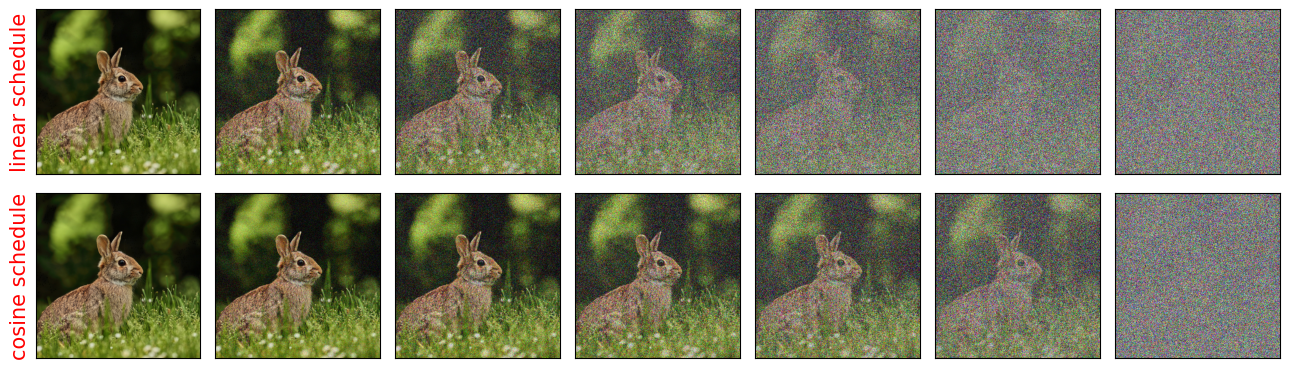

In [ ]:
def cosine_noisy_image(image,timestep):    #Defines a function to generate noisy images using the cosine diffusion schedule
    alphabar_t=cosine_scheduler()["sqrtab"][timestep]
    noisy=image*torch.sqrt(alphabar_t)+\
        torch.randn_like(image)*torch.sqrt(1 - alphabar_t)
    return torch.clip(noisy,min=-1,max=1)

img=np.array(PIL.Image.open("files/bunny.png"))
img=torch.tensor(2*(img/255)-1)
imgs=[]

for timestep in [0,166,332,498,664,830,996]:    #Generates noisy images using the linear diffusion schedule
    imgs.append(linear_noisy_image(img,timestep)/2+0.5)
for timestep in [0,166,332,498,664,830,996]:    #Generates noisy images using the cosine diffusion schedule
    imgs.append(cosine_noisy_image(img,timestep)/2+0.5)

plt.figure(figsize=(13,4),dpi=100)
for i in range(14):    #Plots the noisy images in two rows and seven columns
    plt.subplot(2,7,i+1)
    plt.imshow(imgs[i])
    plt.xticks([])
    plt.yticks([])
    if i==0:
        plt.ylabel("linear schedule",fontsize=15,c="r")
    if i==7:
        plt.ylabel("cosine schedule",fontsize=15,c="r")
plt.tight_layout()
plt.show()


In the figure above, we gradually add noise to a clean image under a linear diffusion schedule
(top row) and a cosine diffusion schedule (bottom row). The first column contains
clean images (i.e., $t = 0$). As we move to the right, the time steps are $166, 332, 498, 664, 830,$ and $996$, respectively. The linear diffusion schedule adds noise to the image more
quickly, while the cosine diffusion schedule adds noise more gradually over time.

The top row of images shows how noise is added to the bunny image under the linear
diffusion schedule. The bottom row shows how noise is added to the same bunny
image under the cosine diffusion schedule. As we can see, noise is added to the image
more gradually and more evenly over time under the cosine diffusion schedule. This is
why the cosine diffusion schedule leads to better performance. However, the linear diffusion
schedule is easier to code and implement. Which diffusion schedule to choose
depends on the specific task and the balance between performance and implementation
complexity.

# 2. The Reverse Diffusion Process

Now that we understand the forward diffusion process, let’s discuss the reverse diffusion
process (i.e., the denoising process). If we can train a model to reverse the forward
diffusion process, we can feed the model with random noise and ask it to produce
a less noisy image. We can iteratively repeat the process for many time steps until we
obtain a clean image. A U-Net is the key building block of a denoising diffusion model,
which we will elaborate on in this laboratory and the next.

A *U-Net* is a type of neural network commonly used in denoising diffusion models
due to its ability to process and generate high-quality images. It typically uses convolutional
neural networks (CNNs) to extract spatial features from the input images. U-Nets
have an encoder–decoder structure with skip connections that directly link layers of
the same resolution in the encoder and decoder. This design allows the U-Net to capture
both global context and fine-grained details, making it well-suited for tasks such as
denoising and image generation.

In the context of diffusion models, the U-Net learns to reverse the diffusion process
by predicting the noise at each step, enabling the gradual reconstruction of clean
images from noisy inputs. In the next laboratory, we will learn how to create a U-Net from
scratch. In this laboratory, we will use the U-Net from the `diffusers` library. We run the following
code cell to install the `diffusers` library:

In [ ]:
!pip install diffusers

In the forward diffusion process, we add noise to the image in time step $t$, $x_t$, to obtain the
image in time step $t + 1$, $x_{t+1}$, based on a function $q(x_{t+1}|x_t)$. However, upon observing $x_{t+1}$,
we can’t obtain $x_t$ because the function $q(x_t|x_{t+1})$ is unknown. Therefore, we need to use
the training data to teach a model to approximate the conditional probability $p_θ(x_t|x_{t+1})$,
where $θ$ represents the model parameters. The idea is shown in the figure below.

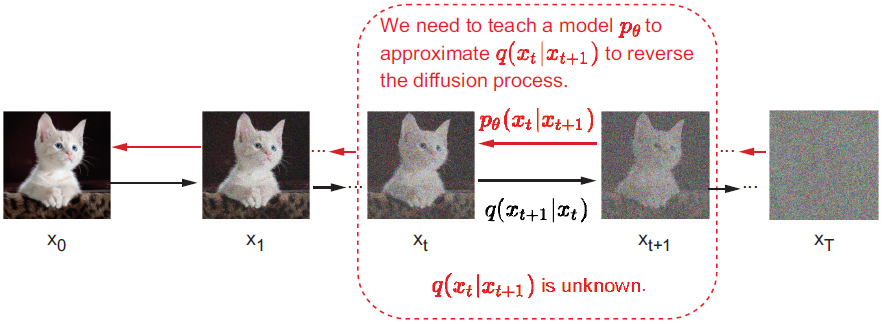

In this laboratory, we will import the U-Net model from the `diffusers` library and treat it as a black box. Doing so allows us to focus on the training process
of the U-Net (instead of creating one from scratch). The denoising U-Net takes a
noisy image, $x_t$, and the time step it is in, $t$, as inputs. The output is the noise injected
into the noisy image, $\epsilon$. Knowing the noise $\epsilon$ allows us to back out the original clean
image $x_0$ based on equation $(4)$. U-Net can capture both local and global context,
where local context involves information from a small, immediate neighborhood
around each pixel, while the global context refers to the broader, overall structure
of the image. This makes it effective for removing noise while preserving important
details such as edges and textures. We will discuss more on the U-Net architecture in the next laboratory.

In [ ]:
import diffusers, torch

device="cuda" if torch.cuda.is_available() else "cpu"
model=diffusers.UNet2DModel(sample_size=32,    #Specifies the width and height of the input and output images
                    in_channels=1,
                    out_channels=1,layers_per_block=2,
    block_out_channels=(128,128,256,512),    #Defines the number of feature maps each block will output
    down_block_types=("DownBlock2D","DownBlock2D",    #Specifies the types of blocks used in the encoder in the U-Net
                      "AttnDownBlock2D","DownBlock2D",),
    up_block_types=("UpBlock2D","AttnUpBlock2D",    #Specifies the types of blocks used in the decoder in the U-Net
                "UpBlock2D","UpBlock2D",),).to(device)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


The `UNet2DModel` class in the `diffusers` library creates a U-Net model based on several
arguments. The `sample_size` argument specified the width and height of the input
and output images. We set the value to `32` because we will resize the clothing-item images
from $1 × 28 × 28$ to $1 × 32 × 32$ to fit the `UNet2DModel` class specification.

The argument `block_out_channels` defines the number of feature maps (channels)
that each block in the U-Net will output. As we will learn in the next couple of laboratories, U-Net is built with an encoder–decoder architecture. The encoder progressively
reduces the spatial dimensions of the input through downsampling while increasing
the depth (number of channels). The decoder progressively increases the spatial
dimensions through upsampling while refining the depth.

The `down_block_types` and `up_block_types` parameters define the types of blocks
used in the encoder (downsampling) and decoder (upsampling) parts of the U-Net
architecture, respectively. These parameters allow us to customize the architecture
of the U-Net by choosing different block types, including those with attention mechanisms.
The attention mechanism allows the model to focus on specific parts of the input
or output features.

The input to the model is a noisy image, $x_t$, along with the time step the image is in, $t$.
The model will predict the noise in the image. Once we know the noise in the image, we
can back out the original clean image $x_0$.

# 3. A Blueprint to Train the U-Net Model
In this section, we will discuss the steps in training a denoising U-Net model. We will then
preprocess the training data to get it ready for the next section when we perform the
actual training.

## 3.1.	Steps in Training a Denoising U-Net Model

The denoising U-Net takes a noisy image and the time step it is in as inputs. The output
is the noise injected into the noisy image. The model is trained to minimize the difference
between the output (predicted noise) and the ground truth (actual noise).

The denoising U-Net model uses the U-Net architecture’s ability to capture both
local and global contexts. These models are widely used in various applications, including
medical image denoising and photographic image restoration. The figure below shows the
steps in training a denoising U-Net model.

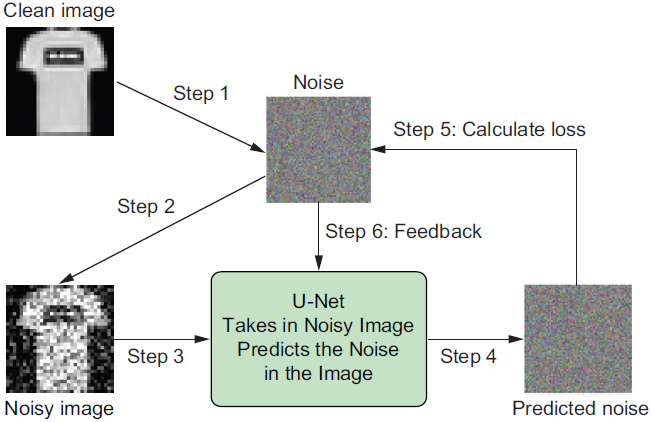

We first obtain clean clothing-item images as our training set (step $1$). Each batch of
training data contains $128$ images. We randomly choose a time step $t$ for each of these
$128$ images where the value of $t$ ranges from $1$ to $1,000$. We add noise to these clean
images depending on the value of $t$ for each image based on the formula in equation $(4)$. We present the $128$ noisy images (step $2$), along with the time steps these images are in, to the U-Net model (step $3$). The model predicts the noise in the noisy images (step
$4$). We compare the predicted noise with the ground truth (the actual noise injected
into the images) and calculate the loss, which is measured by the L1 loss (mean absolute
error; step $5$). We adjust the model parameters to minimize the loss (step $6$).

## 3.2. Preprocessing the Training Data

We will use the Fashion MNIST dataset in this project. We will use the `datasets` and
`transforms` packages in the TorchVision library, as well as the `Dataloader` packages in
PyTorch to help preprocess data.

In the following code block, we first import needed libraries and instantiate a
`Compose` class in the `transforms` packages to transform raw images to PyTorch tensors:

In [ ]:
from torchvision import transforms

torch.manual_seed(42)    #Fixes the random state so results are reproducible

tf = transforms.Compose(
    [transforms.Resize((32,32)),transforms.ToTensor(),
     transforms.Lambda(lambda x: 2*(x-0.5)),]    #Converts images to PyTorch tensors with values in the range [–1,1]
)


The `manual_seed()` method in PyTorch is used to fix the random state so that results
are reproducible. The `transforms` package in TorchVision can help create a series of
transformations to preprocess images. We resize the images from $(1, 28, 28)$ to $(1, 32,
32)$ so that the images fit the input dimensions of the U-Net model we created in the
preceding section. The upscaling is a cost of using an off-the-shelf U-Net model here.
In the next laboratory, we will create our own U-Net from scratch with no need to upscale
the input image. The `ToTensor()` function converts image data (in either PIL image formats
or NumPy arrays) into PyTorch tensors. In particular, the image data are integers
ranging from $0$ to $255$, and the `ToTensor()` function converts them to float tensors with values between $0.0$ and $1.0$. We then normalize the input data to the range $[−1, 1]$ for
faster convergence during training, which we will do often.

Next, we use the `datasets` package in TorchVision to download the dataset to a folder and perform the transformation:

In [ ]:
import torchvision

dataset = torchvision.datasets.FashionMNIST(
    r".",
    train=True,
    download=True,
    transform=tf,
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 213kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.59MB/s]


There are $10$ different types of clothing items. The labels in the dataset are numbered
from $0$ to $9$. The list `text_labels` contains the $10$ text labels corresponding to
the numerical labels $0$ to $9$. For example, if an item has a numerical label of $0$ in the
dataset, the corresponding text label is “t-shirt”. The list `text_labels` is defined as
follows:

In [ ]:
text_labels=['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

We can plot the data to visualize the clothes items in the dataset as follows:

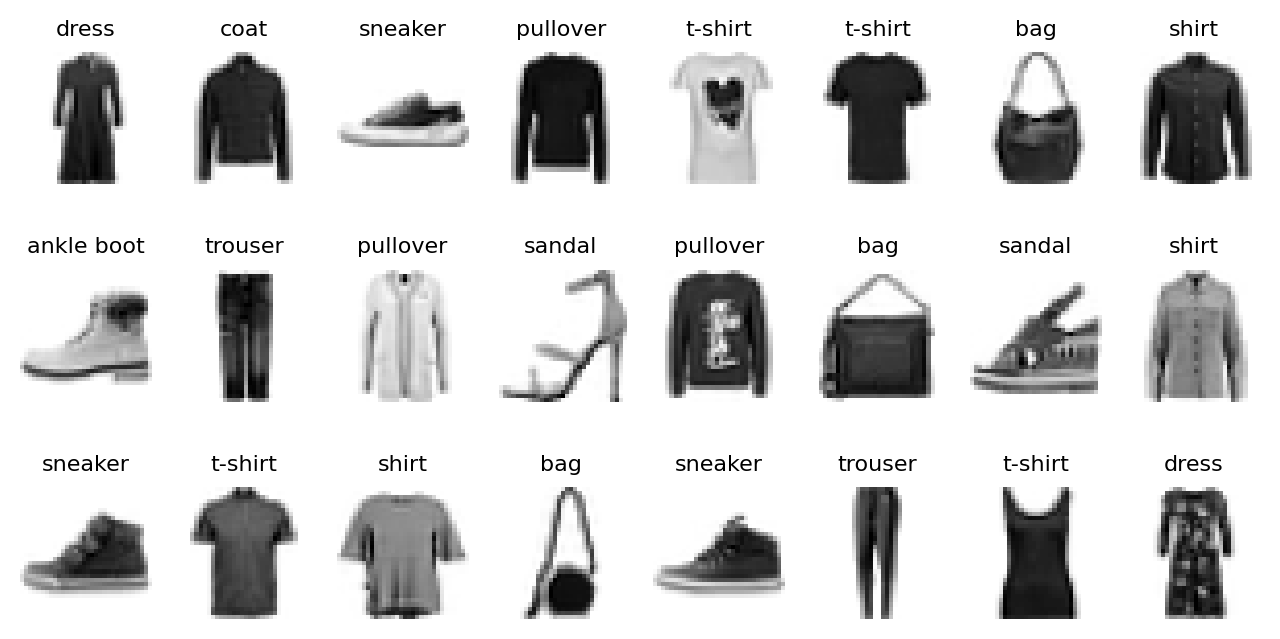

In [ ]:
import matplotlib.pyplot as plt
plt.figure(dpi=200,figsize=(8,4))
for i in range(24):
    ax=plt.subplot(3, 8, i + 1)
    img=dataset[i+888][0]
    img=img/2+0.5
    img=img.reshape(32,32)
    plt.imshow(img,
    cmap="binary")
    plt.axis('off')
    plt.title(text_labels[dataset[i+888][1]],fontsize=8)
plt.show()


We group the training data into batches to maximize computational efficiency. Batch
processing enables parallel computation on GPUs and CPUs, allowing the model to
update its weights more efficiently and significantly speeding up training:

In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

Now we are ready to train the denoising U-Net model we just created. We tackle that
next in the following section.

# 4. Training and Using the Diffusion Model

In the preceding section, we created a denoising U-Net model and prepared the training
data. In this section, we will train the model and use it to generate clean clothing-item
images.

To that end, we will first create a noise scheduler using the `diffusers` library to add
noise to clean images to obtain noisy images. We will then use the noisy images, along
with the time steps the images are in, to train the denoising U-Net.

Once the model is trained, we will feed random noise to the model to generate a noisy
image. We will then feed the noisy image to the trained model to produce a less noisy
image. We repeat the denoising process over many (say, $1,000$) time steps. As a result,
we obtain a clean image that is indistinguishable from those in the training dataset.

## 4.1. The Denoising Diffusion Probabilistic Model (DDPM) Noise Scheduler

Earlier in the laboratory, we discussed the idea behind noise schedulers. In the next laboratory,
we will code from scratch a full-fledged noise scheduler that can handle both the
forward and the reverse diffusion processes. In this laboratory, we will rely on one of the
noise schedulers in the `diffusers` library. Specifically, we define the Denoising Diffusion
Probabilistic Model (DDPM) noise scheduler in our model as follows:

In [ ]:
noise_scheduler = diffusers.DDPMScheduler(
    num_train_timesteps=1000,
  beta_schedule="squaredcos_cap_v2")

The `DDPMScheduler` class from the `diffusers` library is used here. The argument `num_train_timesteps=1000` specifies the number of time steps used in the forward diffusion
process. This choice of $1,000$ steps is the standard practice in most diffusion models
because it strikes a practical balance between image quality and computational efficiency.
Too few steps can make the denoising process too abrupt, resulting in poorer
image quality, while too many steps significantly increase computation time with only
marginal gains in sample quality.

The `squaredcos_cap_v2` diffusion scheduler is a component of the `diffusers` library,
specifically used in the DDPM framework. Here, *probabilistic* means that the entire diffusion
and denoising process is governed by probability distributions, capturing the
inherent randomness and uncertainty in image generation rather than following a single
deterministic path. This scheduler is responsible for managing the diffusion process,
which involves gradually adding noise to an image and then learning to denoise
it to generate new samples. It uses a cosine-based schedule with specific adjustments to
improve the training stability and sample quality. `squaredcos_cap_v2` modifies the noise
schedule to better match the denoising process, potentially leading to better sample
quality. The `cap` in the name indicates that there is a capping mechanism to ensure that
noise levels don’t exceed certain limits, preventing excessive noise addition and helping
maintain stability.

## 4.2. Inference Using the U-Net Denosing Model

During training, we will periodically ask the model to generate clean images so that we
can monitor the performance of the model. For that purpose, we define the following
`sample()` function.

In [ ]:
@torch.no_grad()
def sample(n_sample, model, noise_scheduler,seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    noise_scheduler.set_timesteps(1000)
    image=torch.randn((n_sample,1,32,32)).to(device) #Starts with pure random noise
    for t in noise_scheduler.timesteps: #Iterates over many time steps
        model_output=model(image,t)['sample'] #Predicts the noise in the image using the trained model
        image=noise_scheduler.step(model_output,int(t), #Backs out what the image looks like in the previous time step
                       image,generator=None)['prev_sample']
    return image

The `@torch.no_grad()` decorator in PyTorch is used to disable gradient computation
during the execution of a block of code or a function. This is useful in scenarios where
we don’t need to calculate gradients, such as during model inference or evaluation, as
it improves performance and reduces memory consumption. The `sample()` function
we defined previously is used to generate images using the trained model,
so we use the `@torch.no_grad()` decorator to disable gradient computation.

The `sample()` function takes several arguments. The first argument `n_sample` specifies
how many images we want to generate. The argument `model` is the denoising U-Net
model we want to use to generate images, and the `noise_scheduler` argument specifies
the noise scheduler to use. Finally, we can choose a random seed if we want to reproduce
the results.

## 4.3. Training and Using the Denoising U-Net Model

To train the model, we will adjust model parameters to minimize the difference (measured
by mean absolute error) between the predicted noise and the actual noise. We will
use the AdamW optimizer with a learning rate of $0.0002$ to update model parameters
during training:

In [ ]:
optim = torch.optim.AdamW(model.parameters(), lr=2e-4)

We will use PyTorch’s automatic mixed-precision package `torch.amp` to speed up training,
as we did in previous laboratories. The following code block trains the denoising
U-Net model.

In [ ]:
from tqdm import tqdm
from torchvision.utils import save_image, make_grid

scaler = torch.amp.GradScaler("cuda")
for i in range(10):    #Trains the model for 10 epochs
    pbar = tqdm(dataloader)
    loss_ema = None
    for x, _ in pbar:
        x = x.to(device)
        with torch.amp.autocast("cuda"):
            noise=torch.randn_like(x).to(device)
            timesteps=torch.randint(0,
                    noise_scheduler.config.num_train_timesteps,
                                    (x.shape[0],),device=device)
            noisy=noise_scheduler.add_noise(x, noise, timesteps)
            noise_pred=model(noisy,timesteps)["sample"]    #Predicts the amount of noise injected into the images
            loss = torch.nn.functional.l1_loss(noise_pred,noise)
        optim.zero_grad()
        scaler.scale(loss).backward()    #Adjusts model parameters to minimize L1 loss
        scaler.step(optim)
        scaler.update()
        if loss_ema is None:
            loss_ema = loss.item()
        else:
            loss_ema = 0.9 * loss_ema + 0.1 * loss.item()
        pbar.set_description(f"loss: {loss_ema:.4f}")
    xh = sample(32, model, noise_scheduler)
    grid = make_grid(0.5-xh/2, nrow=8)    #Visually checks the generated images by the model after each epoch
    save_image(grid, f"files/diffusion_fashion{i}.png")
torch.save(model.state_dict(), "files/diffusion_fashion.pth")


loss: 0.1177:  50%|█████     | 235/469 [01:54<01:54,  2.05it/s]


KeyboardInterrupt: 

For simplicity, we train the model for $10$ epochs. We can use early stopping to determine
how many epochs to train, as we did in Laboratory 2. We iterate through all batches
in the training dataset and inject noise into images to obtain noisy images. We then
use the U-Net model to predict the amount of noise in these images. We compare the
predictions with the actual amount of noise to calculate the L1 loss. We then tweak the
model parameters to minimize this loss.

After each epoch, we use the `sample()` function we defined before to produce $32$
clean images using the U-Net model. These images are saved so that
we can visually inspect the results throughout training.

After training, the trained model is saved. Alternatively, the trained model can be downloaded from https://drive.google.com/file/d/1YQdV-bF9sp_tJkd7jReIfv3MeyfnMaB3/view?usp=sharing. Unzip the
file after downloading. We load up the trained model parameters and generate some
images.

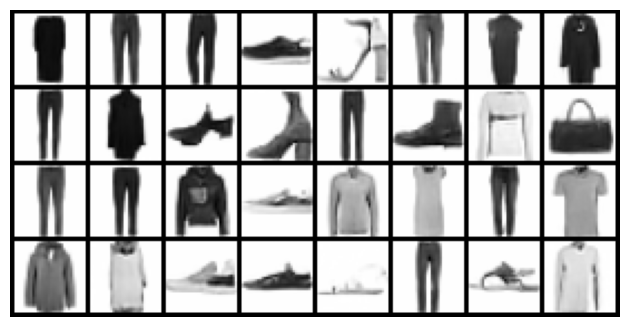

In [ ]:
torch.manual_seed(42)
model.load_state_dict(torch.load(
    "files/diffusion_fashion.pth",
         map_location=device,
         weights_only=True))    #Loads the trained model weights
generated_images = sample(32, model, noise_scheduler)    #Generates 32 images using the sample() function defined before
grid = make_grid(0.5-generated_images/2, nrow=8)
save_image(grid, f"files/diffusion_fashion.png")
plt.figure(dpi=100)
plt.imshow(grid.cpu().permute(1,2,0))    #Plots the images in a 4 × 8 grid
plt.axis('off')
plt.tight_layout()
plt.show()


There are $10$ different types of clothing items, and the model randomly generates
images from one of these $10$ types. As we can see, the trained denoising U-Net model
generates clothing item images resembling those in the training dataset.

If we are wondering whether we can guide the model to generate specific items, such
as a sandal, a t-shirt, or a coat, the answer is yes! In the next laboratory, we will learn how to
design and train a diffusion model to use conditioning information (e.g., the label of a
clothing item) to generate the type of item we are looking for.

# Exercises



1.   Download the images [`bunny.png`](https://drive.google.com/file/d/1t7WnYrrwnUxbMZ38Cv6Gv41n-tVKjyHF/view?usp=drive_link) and [`cat.png`](https://drive.google.com/file/d/1yuhkdo6mCjV1Lage2eTT5WIbi0HXo0yz/view?usp=sharing). Place them in the `files` folder. Iterate through the two images and the time steps $0, 250, 500, 750,$ and $1,000$. Use the function `linear_noisy_
image()` to generate $10$ images. Plot the $10$ images in a $2 × 5$ grid.

2.   Download the image [`cat.png`](https://drive.google.com/file/d/1yuhkdo6mCjV1Lage2eTT5WIbi0HXo0yz/view?usp=sharing), and place it under
the `files` folder. Gradually add noise to the image, and save
the images in time steps $0, 199, 399, 599, 799,$ and $999$ under the linear diffusion
schedule first and then the cosine diffusion schedule. Plot the images in a $2 × 6$ grid.



3.   Set the PyTorch random state to $0$. Use the trained model to generate $16$ images, and
plot them in a $2 × 8$ grid.

